In [1]:
import bw2data, bw2io, bw2calc
import numpy as np
import os
import re
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

### static LCI +  three GWP
- GWP100
- pGWP-fixed vs. dp-CO2 

In [2]:
wind  = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/wind_CN_US_staticLCI_threeGWP100.xlsx")
hydro = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/hydro_run-of-river_CN_US_staticLCI_threeGWP100.xlsx")
pv    = pd.read_excel("dp-LCI_output/staticLCI_(p)GWP100/PV_CN_US_staticLCI_threeGWP100.xlsx")

In [3]:

def tidy(df, tech_label):
    parts = df["Activity"].str.split(", ", expand=True)
    out = df.copy()
    out["Technology"] = tech_label
    out["Country"]    = parts[3].str[:2]
    out["SSP"]        = parts[4]
    out["Year"]       = parts[5].astype(int)
    return out[["Technology", "Country", "SSP", "Year",
                "gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]]

all_df = pd.concat(
    [tidy(wind,  "Wind"),
     tidy(hydro, "Hydro"),
     tidy(pv,    "PV")],
    ignore_index=True,
)

# Keep only 2030 & 2050
df = all_df[all_df["Year"].isin([2030, 2050])].copy()

# long format over metrics
metric_cols = ["gwp100", "pGWP100_fixedCO2", "pGWP100_dpCO2"]
df_long = df.melt(
    id_vars=["Technology", "Country", "SSP", "Year"],
    value_vars=metric_cols,
    var_name="Metric",
    value_name="Score",
)

df_long


,Technology,Country,SSP,Year,Metric,Score
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832
2,Wind,CN,SSP2-M,2030,gwp100,0.037723
3,Wind,CN,SSP2-M,2050,gwp100,0.031185
4,Wind,CN,SSP5-H,2030,gwp100,0.038734
...,...,...,...,...,...,...
103,PV,US,SSP1-VLLO,2050,pGWP100_dpCO2,0.006184
104,PV,US,SSP2-M,2030,pGWP100_dpCO2,0.020048
105,PV,US,SSP2-M,2050,pGWP100_dpCO2,0.012654
106,PV,US,SSP5-H,2030,pGWP100_dpCO2,0.020952


#### adding:  dpLCI + pGWP-fixedCO2

In [4]:

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/hydro_dp_results_MY2030_2050.pkl","rb") as f:
    hydro_dp = pickle.load(f)

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/PV_dp_results_MY2030_2050.pkl","rb") as f:
    pv_dp = pickle.load(f)

with open("dp-LCI_output/dpLCI_pGWP-fixed_pickle/wind_dp_results_allMY.pkl","rb") as f:
    wind_dp = pickle.load(f)


# extract the new dp metrics and produce a DataFrame with exact columns:
# Activity, Technology, Country, SSP, Year, Metric, Score
# ONLY WANNA 2030 & 2050 as two MY:: 

def extract_from_dp_dict(dp_dict):
    rows = []

    # map activity string tech → tidy Technology label
    tech_map = {
        "wind": "Wind",
        "PV": "PV",
        "hydro": "Hydro",
    }

    #####   we need to convert all US-xx / CN-xx country code to just US/CN 
    def collapse_country(region):
        """Collapse ecoinvent/IAM region to CN or US."""
        if region.startswith("US"):
            return "US"
        if region.startswith("CN"):
            return "CN"
        # if you ever have other regions, either return as-is or map them too
        return region

    for act, metrics in dp_dict.items():
        parts = act.split(", ")

        raw_tech = parts[1]              # 'wind' / 'photovoltaic' / 'hydro'
        if raw_tech not in tech_map:
            print(row_tech)
            continue                     # skip unexpected techs

        tech        = tech_map[raw_tech]
        region      = parts[3]           # e.g. 'US-TRE', 'CN-NM'
        country     = collapse_country(region)
        ssp         = parts[4]
        year        = int(parts[5])

        # keep only 2030 & 2050
        if year not in (2030, 2050):
            continue

        for metric_name, value in metrics.items():
            rows.append(
                {
                    "Technology": tech,
                    "Country": country,   # NOW only 'US' or 'CN'
                    "SSP": ssp,
                    "Year": year,
                    "Metric": metric_name,
                    "Score": float(value),
                }
            )

    return pd.DataFrame(rows)



df_hydro_dp = extract_from_dp_dict(hydro_dp)
df_pv_dp    = extract_from_dp_dict(pv_dp)
df_wind_dp  = extract_from_dp_dict(wind_dp)

df_dp = pd.concat([df_hydro_dp, df_pv_dp, df_wind_dp], ignore_index=True)
print(len(df_dp)) # should be 72, so that 72/2(new metric) == 36
df_dp


72


,Technology,Country,SSP,Year,Metric,Score
0,Hydro,US,SSP5-H,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004793
1,Hydro,US,SSP5-H,2030,"full dp-LCI, pGWP100-fixedCO2",0.004745
2,Hydro,US,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.004835
3,Hydro,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.004956
4,Hydro,CN,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.003733
...,...,...,...,...,...,...
67,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138
68,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229
69,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193
70,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520


In [5]:
#df_dp 
df_full = pd.concat([df_long, df_dp], ignore_index=True)
#df_full

#### now ranking 

In [6]:
# NOW recompute Rank with the two new metrics included
df_full["Rank"] = df_full.groupby(
    ["Country","SSP","Year","Metric"]
)["Score"].rank(method="dense", ascending=True)

df_full

,Technology,Country,SSP,Year,Metric,Score,Rank
0,Wind,CN,SSP1-VLLO,2030,gwp100,0.036905,3.0
1,Wind,CN,SSP1-VLLO,2050,gwp100,0.017832,3.0
2,Wind,CN,SSP2-M,2030,gwp100,0.037723,3.0
3,Wind,CN,SSP2-M,2050,gwp100,0.031185,3.0
4,Wind,CN,SSP5-H,2030,gwp100,0.038734,3.0
...,...,...,...,...,...,...,...
175,Wind,US,SSP1-VLLO,2030,"full dp-LCI, pGWP100-fixedCO2",0.024138,3.0
176,Wind,US,SSP2-M,2050,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.017229,3.0
177,Wind,US,SSP2-M,2050,"full dp-LCI, pGWP100-fixedCO2",0.021193,3.0
178,Wind,CN,SSP1-VLLO,2030,"dyn FG LCI static BG p-LCI, pGWP100-fixedCO2",0.041520,3.0


In [7]:
metric_rename = {
    "gwp100": "staticLCI + IPCC-GWP",
    "pGWP100_fixedCO2": "staticLCI + pGWP-fixedCO2",
    "pGWP100_dpCO2": "staticLCI + pGWP-dpCO2",
    "dyn FG LCI static BG p-LCI, pGWP100-fixedCO2": "dyn-FG-LCI + pGWP-fixedCO2",
    "full dp-LCI, pGWP100-fixedCO2": "full dpLCI + pGWP-fixedCO2"
}


In [8]:
df_full["Metric"] = df_full["Metric"].replace(metric_rename)

In [9]:
df_full_sorted = df_full.sort_values([ "SSP","Year", "Country", "Technology"	]) 
df_full_sorted

,Technology,Country,SSP,Year,Metric,Score,Rank
12,Hydro,CN,SSP1-VLLO,2030,staticLCI + IPCC-GWP,0.004278,1.0
48,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-fixedCO2,0.004835,1.0
84,Hydro,CN,SSP1-VLLO,2030,staticLCI + pGWP-dpCO2,0.004232,1.0
126,Hydro,CN,SSP1-VLLO,2030,dyn-FG-LCI + pGWP-fixedCO2,0.004835,1.0
127,Hydro,CN,SSP1-VLLO,2030,full dpLCI + pGWP-fixedCO2,0.004956,1.0
...,...,...,...,...,...,...,...
11,Wind,US,SSP5-H,2050,staticLCI + IPCC-GWP,0.019234,3.0
47,Wind,US,SSP5-H,2050,staticLCI + pGWP-fixedCO2,0.017215,3.0
83,Wind,US,SSP5-H,2050,staticLCI + pGWP-dpCO2,0.019006,3.0
168,Wind,US,SSP5-H,2050,dyn-FG-LCI + pGWP-fixedCO2,0.017215,3.0


In [10]:
df_full_sorted.to_excel("plot_rankshift_five_metrics.xlsx")

### plot 

#### function

In [11]:
def rank_shift_plot_cleanSeparated(
    df_long,
    metric_order,
    metric_labels,
    tech_colors,
    fig_title="Rank shifts across GWP metrics",
    years=(2030, 2050),
    countries=("CN", "US"),
    ssps=("SSP1-VLLO", "SSP2-M", "SSP5-H"),
    lw=3.0,
    sep=0.03,      # vertical separation between 2030 and 2050
    anot_off=0.12  # distance from line to annotation
):


    df = df_long.copy()
    df["Rank"] = (
        df.groupby(["Country", "SSP", "Year", "Metric"])["Score"]
          .rank(method="dense", ascending=True)
    )

    dotted_2050 = (0, (1, 3))
    year_ls    = {2030: "solid", 2050: dotted_2050}
    year_alpha = {2030: 1.0,     2050: 0.9}
    # 2030 always on top of 2050
    zmap = {2030: 5, 2050: 4}

    fig, axes = plt.subplots(
        nrows=len(ssps),
        ncols=len(countries),
        figsize=(14, 10),
        sharex=True,
        sharey=True,
    )
    plt.subplots_adjust(top=0.88, bottom=0.20, hspace=0.35, wspace=0.18)

    x = np.arange(len(metric_order))

    for i, ssp in enumerate(ssps):
        for j, ct in enumerate(countries):
            ax = axes[i, j]
            sub = df[(df["SSP"] == ssp) & (df["Country"] == ct)]

            for tech in ["Hydro", "PV", "Wind"]:
                sub_t = sub[sub["Technology"] == tech]

                for yr in years:
                    tdf = sub_t[sub_t["Year"] == yr]
                    if tdf.empty:
                        continue

                    y_rank  = tdf.set_index("Metric")["Rank"].reindex(metric_order)
                    y_score = tdf.set_index("Metric")["Score"].reindex(metric_order)

                    # apply separation: 2030 up, 2050 down
                    shift     =  sep if yr == 2030 else -sep
                    y_shifted = y_rank + shift

                    # main line
                    ax.plot(
                        x,
                        y_shifted,
                        linestyle=year_ls[yr],
                        color=tech_colors[tech],
                        alpha=year_alpha[yr],
                        linewidth=lw,
                        marker="x",
                        markersize=7,       
                        zorder=zmap[yr],
                    )

                    # annotations – FIXED DIRECTION
                    for xi, yi, sc in zip(x, y_shifted, y_score):
                        if pd.isna(sc):
                            continue
                        val = sc * 1000.0

                        if yr == 2030:
                            # 2030 ABOVE its line
                            ax.text(
                                xi,
                                yi + anot_off,
                                f"{val:.1f}",
                                ha="center",
                                va="bottom",
                                fontsize=10,
                            )
                        else:
                            # 2050 BELOW its line
                            ax.text(
                                xi,
                                yi - anot_off,
                                f"{val:.1f}",
                                ha="center",
                                va="top",
                                fontsize=10,
                            )

            ax.set_title(f"{ct}, {ssp}", fontsize=14, pad=8)
            ax.set_xticks(x)

            if i == len(ssps) - 1:
                ax.set_xticklabels(
                    [metric_labels[m] for m in metric_order],
                    rotation=25,
                    ha="right",
                    fontsize=12,
                )
            else:
                ax.set_xticklabels([])

            ax.set_yticks([1, 2, 3])
            ax.set_ylim(0.2, 3.8)  # 1 bottom, 3 top
            if j == 0:
                ax.set_ylabel("Rank (1 = lowest GWP)", fontsize=13)

            ax.grid(axis="y", linestyle=":", alpha=0.3)

    # Legend
    handles, labels = [], []
    for tech in ["Hydro", "PV", "Wind"]:
        for yr in years:
            h, = axes[0, 0].plot(
                [],
                [],
                linestyle=year_ls[yr],
                color=tech_colors[tech],
                alpha=year_alpha[yr],
                linewidth=lw,
                marker="x",
                markersize=7,
            )
            handles.append(h)
            labels.append(f"{tech} {yr}")

    fig.legend(
        handles,
        labels,
        title="Technology / Year",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=6,
        fontsize=12,
        frameon=True,
    )

    fig.suptitle(fig_title, fontsize=16, y=0.97)
    return fig, axes


#### plot 

In [20]:
check = (
    df_full_sorted[(df_full_sorted["Country"] == "US") &
            (df_full_sorted["SSP"] == "SSP5-H") &
            (df_full_sorted["Year"] == 2030)]
    .sort_values(["Metric", "Rank"])
)[["Metric","Technology","Score","Rank"]]

print(check)

                         Metric Technology     Score  Rank
108  dyn-FG-LCI + pGWP-fixedCO2      Hydro  0.004793   1.0
136  dyn-FG-LCI + pGWP-fixedCO2         PV  0.023026   2.0
158  dyn-FG-LCI + pGWP-fixedCO2       Wind  0.023320   3.0
109  full dpLCI + pGWP-fixedCO2      Hydro  0.004745   1.0
137  full dpLCI + pGWP-fixedCO2         PV  0.022438   2.0
159  full dpLCI + pGWP-fixedCO2       Wind  0.023088   3.0
22         staticLCI + IPCC-GWP      Hydro  0.004429   1.0
10         staticLCI + IPCC-GWP       Wind  0.021660   2.0
34         staticLCI + IPCC-GWP         PV  0.021726   3.0
94       staticLCI + pGWP-dpCO2      Hydro  0.004362   1.0
106      staticLCI + pGWP-dpCO2         PV  0.020952   2.0
82       staticLCI + pGWP-dpCO2       Wind  0.021230   3.0
58    staticLCI + pGWP-fixedCO2      Hydro  0.004793   1.0
70    staticLCI + pGWP-fixedCO2         PV  0.023026   2.0
46    staticLCI + pGWP-fixedCO2       Wind  0.023320   3.0


### because it's uniform distribution on the FG dyn LCI, 
##### so without full dpLCI (mapping to the right background), it the same score on dyn-FG-LCI vs. static LCI 

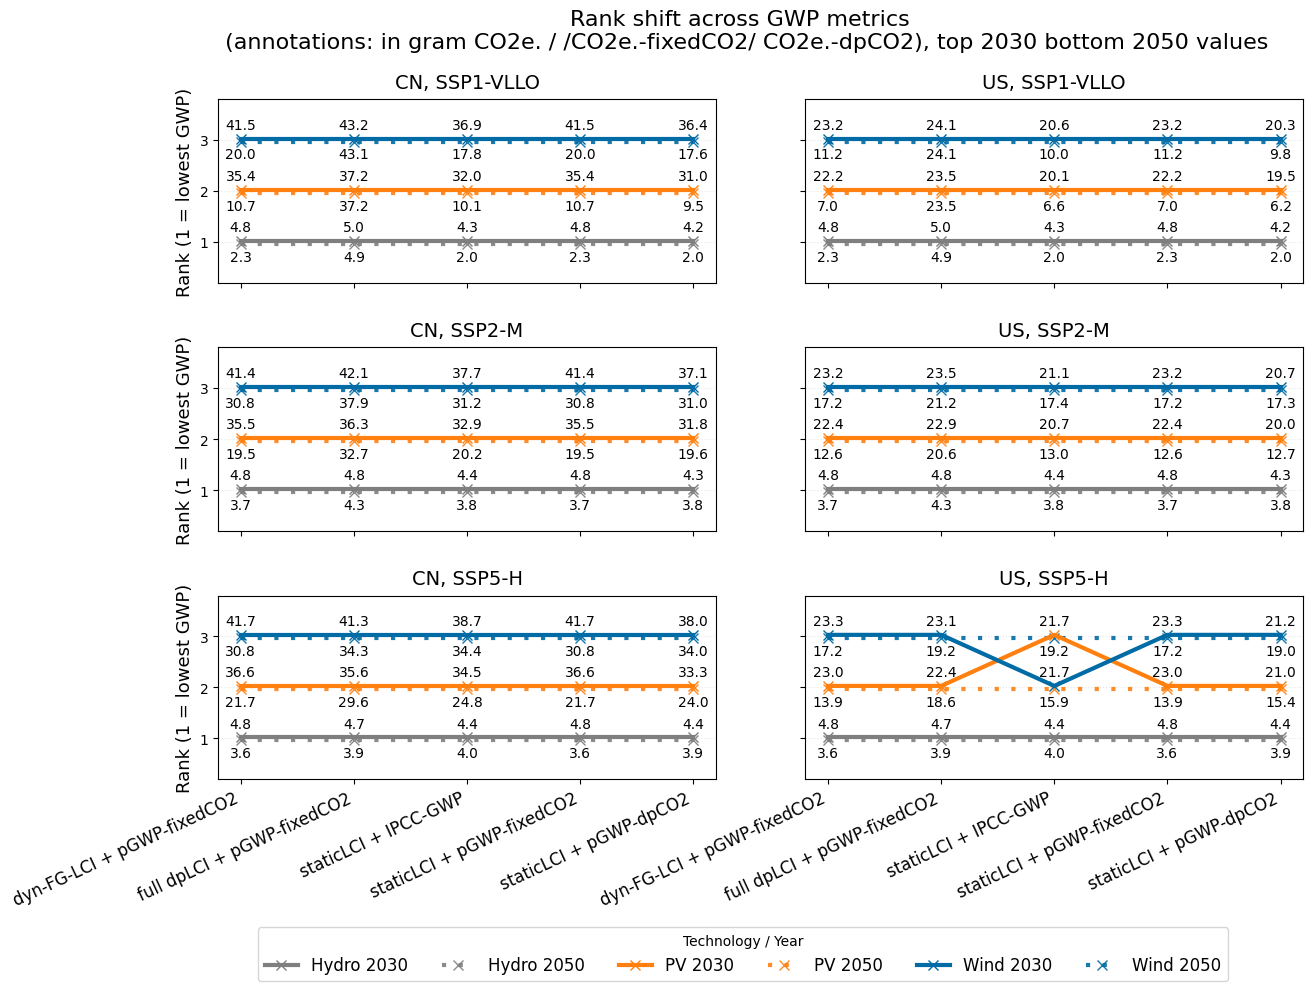

In [21]:
metric_order = [  'dyn-FG-LCI + pGWP-fixedCO2', 'full dpLCI + pGWP-fixedCO2',
                  'staticLCI + IPCC-GWP', 'staticLCI + pGWP-fixedCO2', 'staticLCI + pGWP-dpCO2', 
                ]

metric_labels = {
    'staticLCI + IPCC-GWP': 'staticLCI + IPCC-GWP', 
    'staticLCI + pGWP-fixedCO2':'staticLCI + pGWP-fixedCO2', 
    'staticLCI + pGWP-dpCO2': 'staticLCI + pGWP-dpCO2',   
    'dyn-FG-LCI + pGWP-fixedCO2':'dyn-FG-LCI + pGWP-fixedCO2' ,
    'full dpLCI + pGWP-fixedCO2': 'full dpLCI + pGWP-fixedCO2',
}

tech_colors = {"PV":"#FF800E","Wind":"#006BA4","Hydro":"#7F7F7F"}

fig, axes = rank_shift_plot_cleanSeparated(
    df_full_sorted,
    metric_order=metric_order,
    metric_labels=metric_labels,
    tech_colors=tech_colors,
    fig_title=  "Rank shift across GWP metrics \n (annotations: in gram CO2e. / /CO2e.-fixedCO2/ CO2e.-dpCO2), top 2030 bottom 2050 values",
)